# Assignment-11: Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("retail_sales_dataset.csv") 

print(df.head())
print(df.columns)
print(df.shape)

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')
(1000, 9)


In [3]:
df.columns = df.columns.str.strip()

date_col = "Date"
sales_col = "Total Amount"
category_col = "Product Category"
quantity_col = "Quantity"

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df["Year"] = df[date_col].dt.year
df["Month"] = df[date_col].dt.strftime("%b")
df["Month_Year"] = df[date_col].dt.to_period("M").astype(str)

print(df.head())

   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  Year Month Month_Year  
0         3              50           150  2023   Nov    2023-11  
1         2             500          1000  2023   Feb    2023-02  
2         1              30            30  2023   Jan    2023-01  
3         1             500           500  2023   May    2023-05  
4         2              50           100  2023   May    2023-05  


## Task-1: Line Plot(Sales Trend)

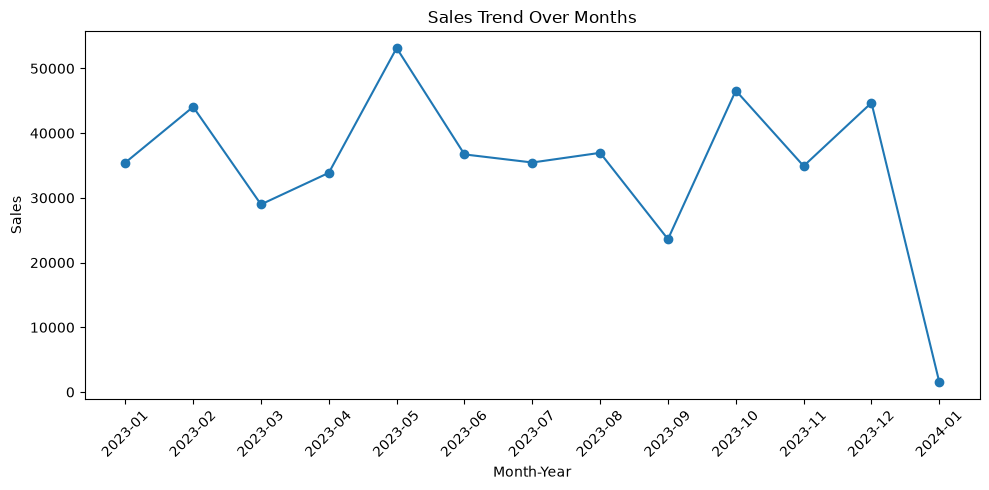

In [5]:
monthly_sales = df.groupby("Month_Year")[sales_col].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["Month_Year"], monthly_sales[sales_col], marker="o")
plt.title("Sales Trend Over Months")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task-2: Scatter Plot

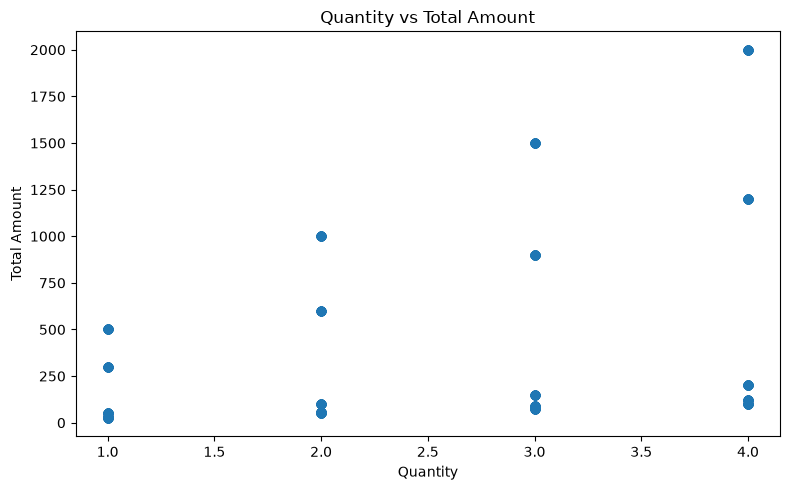

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df[quantity_col], df[sales_col])
plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()

## Task-3: Bar Plot(Vertical & Horizontal)

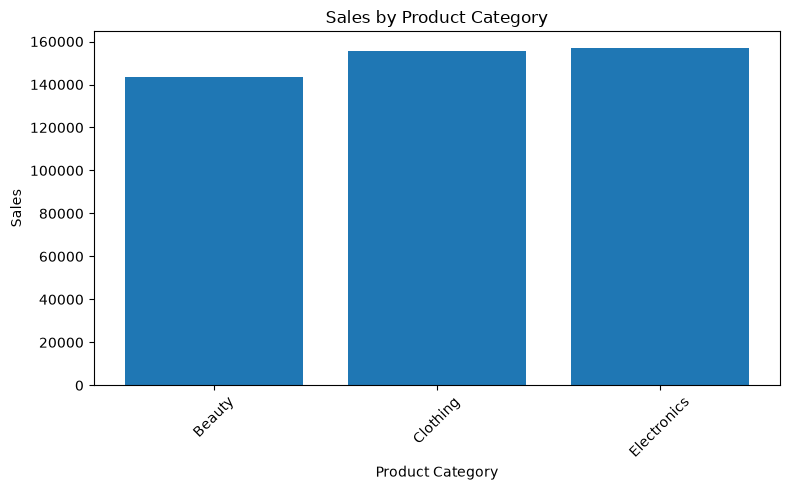

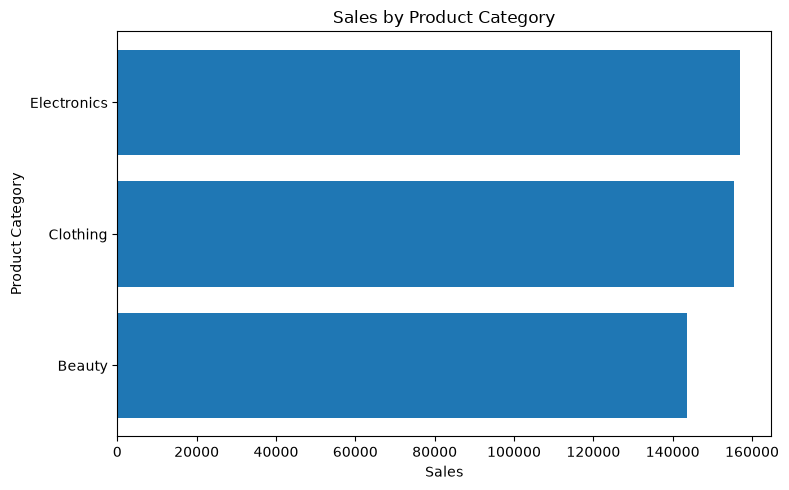

In [7]:
category_sales = df.groupby(category_col)[sales_col].sum().reset_index()

#Vertical
plt.figure(figsize=(8,5))
plt.bar(category_sales[category_col], category_sales[sales_col])
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Horizontal
plt.figure(figsize=(8,5))
plt.barh(category_sales[category_col], category_sales[sales_col])
plt.title("Sales by Product Category")
plt.xlabel("Sales")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

## Task-4: Multiple Bar Plot

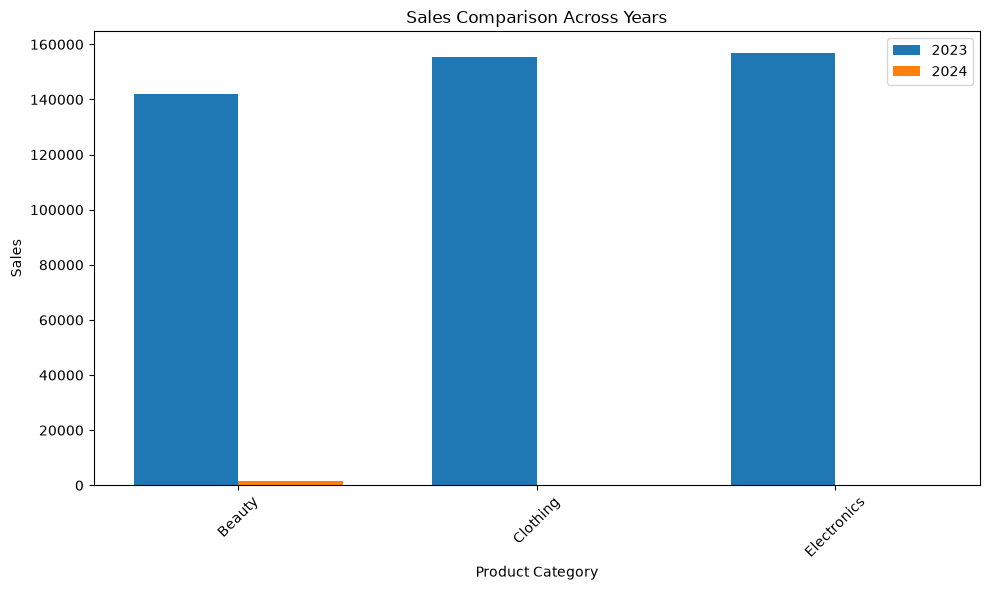

In [8]:
year_category_sales = df.groupby(["Year", category_col])[sales_col].sum().unstack(fill_value=0)

years = year_category_sales.index.tolist()
categories = year_category_sales.columns.tolist()

x=range(len(categories))
bar_width = 0.35

plt.figure(figsize=(10,6))

for i,year in enumerate(years):
    plt.bar(
        [pos + i*bar_width for pos in x],
        year_category_sales.loc[year],
        width=bar_width,
        label=str(year)
    )

plt.title("Sales Comparison Across Years")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.xticks([pos + bar_width / 2 for pos in x], categories, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Task-5: Stacked Bar Chart

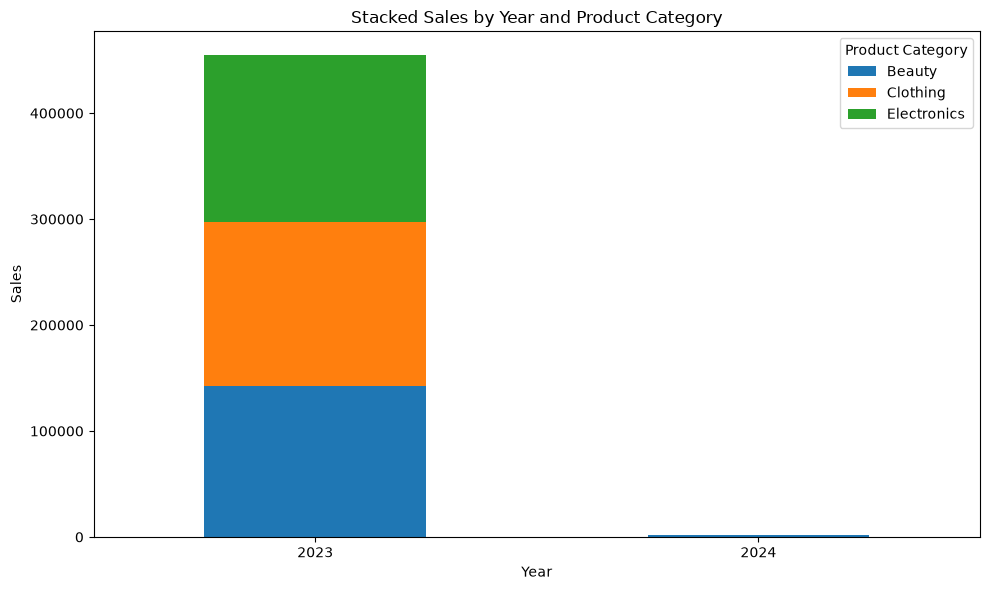

In [9]:
stacked_data = df.groupby(["Year", category_col])[sales_col].sum().unstack(fill_value=0)

stacked_data.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Stacked Sales by Year and Product Category")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.legend(title="Product Category")
plt.tight_layout()
plt.show()

## Task-6: Histogram

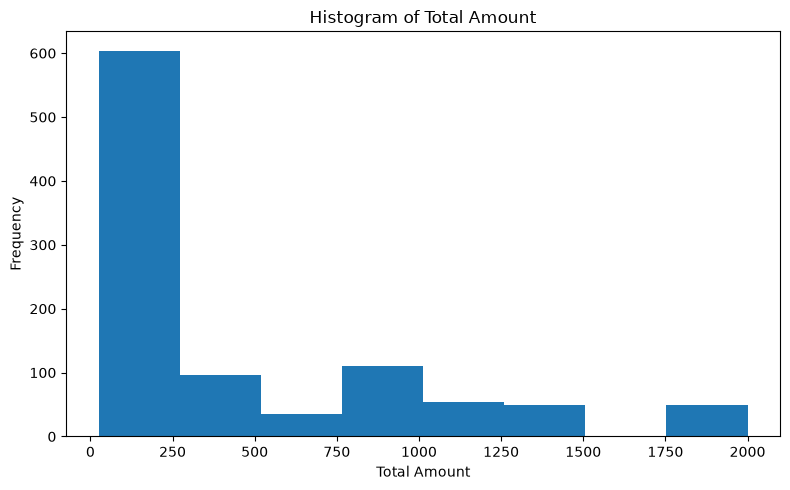

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df[sales_col], bins=8)
plt.title("Histogram of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Task-7: Pie Chart

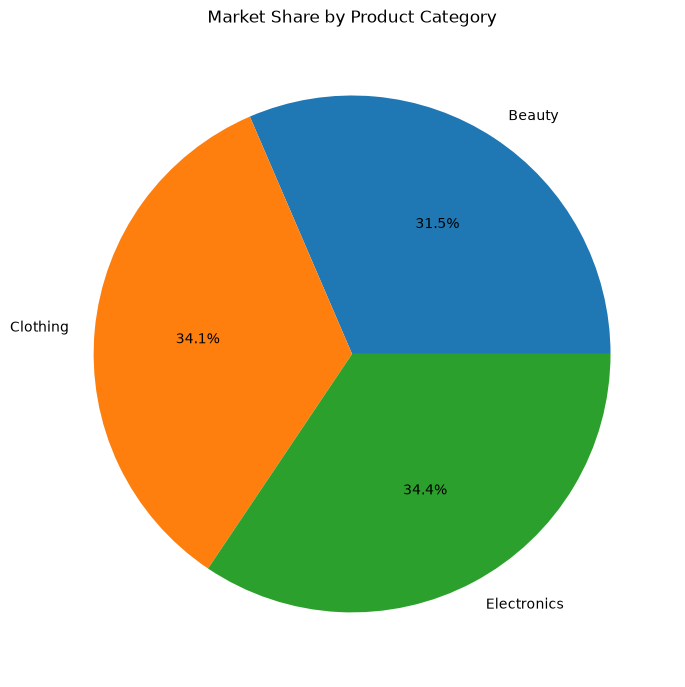

In [11]:
pie_data = df.groupby(category_col)[sales_col].sum()

plt.figure(figsize=(7, 7))
plt.pie(pie_data, labels=pie_data.index, autopct="%1.1f%%")
plt.title("Market Share by Product Category")
plt.tight_layout()
plt.show()